In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## Regression Analysis: State-level

In [2]:
# Load datacenters dataset
data_centers_df_first = pd.read_csv('data_centers_cleaned.csv')

# Load electricity price dataset
electricity_price_df = pd.read_csv('electricity_price_cleaned.csv')

# Add electricity price to datacenters dataset based on state
data_centers_df = data_centers_df_first.merge(
    electricity_price_df[['state', 'electricity_price']],
    on='state',                       
    how='left'
)

display(data_centers_df.head())

# Create geometry column from lat/lon
geometry = [Point(xy) for xy in zip(data_centers_df['lon'], data_centers_df['lat'])]

gdf_data_centers = gpd.GeoDataFrame(data_centers_df, geometry=geometry)

# Set coordinate reference system (WGS84)
gdf_data_centers.set_crs(epsg=4326, inplace=True);

,id,state,state_abb,county,county_id,lat,lon,type,sqft,electricity_price
0,2744301,New Jersey,NJ,Middlesex County,23,40.544256,-74.496521,building,105786.0,13.95
1,9474864,North Carolina,NC,Caldwell County,27,35.894738,-81.546515,campus,3407194.0,7.91
2,13924557,Iowa,IA,Polk County,153,41.515967,-93.711830,campus,11169421.0,6.40
3,14593270,North Carolina,NC,Catawba County,35,35.588771,-81.261809,campus,5431080.0,7.91
4,14930068,New Mexico,NM,Bernalillo County,1,35.049942,-106.542822,building,158463.0,5.13


In [3]:
plants = pd.read_csv("plants_cleaned.csv")

state_abbrev_to_name = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming", "DC": "District of Columbia"
}

plants["state"] = plants["State"].map(state_abbrev_to_name)

# Create geometry column from lat/lon
geometry = [Point(xy) for xy in zip(plants['Longitude'], plants['Latitude'])]

gdf_plants = gpd.GeoDataFrame(plants, geometry=geometry)

# Set coordinate reference system (WGS84)
gdf_plants.set_crs(epsg=4326, inplace=True);

In [4]:
gdf_data_centers_proj = gdf_data_centers.to_crs(epsg=3857)
gdf_plants_proj = gdf_plants.to_crs(epsg=3857)

nearest = gpd.sjoin_nearest(
    gdf_data_centers_proj,
    gdf_plants_proj,
    how="left",
    distance_col="distance_m"
)

nearest["distance_km"] = nearest["distance_m"] / 1000

In [5]:
state_counts = nearest.groupby("State").agg(
    data_center_count=("id", "nunique")
).reset_index()

state_distance = nearest.groupby("State").agg(
    avg_nearest_plants_km=("distance_km", "mean")
).reset_index()

state_plants = plants.groupby("State").agg(
    renewable_capacity_mw=("Nameplate Capacity (MW)", "sum")
).reset_index()

state_price = nearest.groupby("State").agg(
    electricity_price=("electricity_price", "first")
).reset_index()

reg_df = state_counts.merge(state_distance, on="State") \
                     .merge(state_plants, on="State") \
                     .merge(state_price, on="State")

display(reg_df.head())

,State,data_center_count,avg_nearest_plants_km,renewable_capacity_mw,electricity_price
0,AL,8,14.728138,1450.9,7.80
1,AR,2,7.366368,2247.0,6.43
2,AZ,65,5.323576,6083.3,7.22
3,CA,112,6.556774,30928.9,19.86
4,CO,21,10.979751,8121.8,8.83


In [6]:
# Сreate scaled variables

reg_df["renewable_capacity_gw"] = reg_df["renewable_capacity_mw"] / 1000
reg_df["log_data_center_count"] = np.log1p(reg_df["data_center_count"])
sns.set_theme(style="whitegrid")

                              OLS Regression Results                             
Dep. Variable:     log_data_center_count   R-squared:                       0.004
Model:                               OLS   Adj. R-squared:                 -0.020
Method:                    Least Squares   F-statistic:                    0.1594
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):              0.692
Time:                           01:22:24   Log-Likelihood:                -69.730
No. Observations:                     43   AIC:                             143.5
Df Residuals:                         41   BIC:                             147.0
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercep

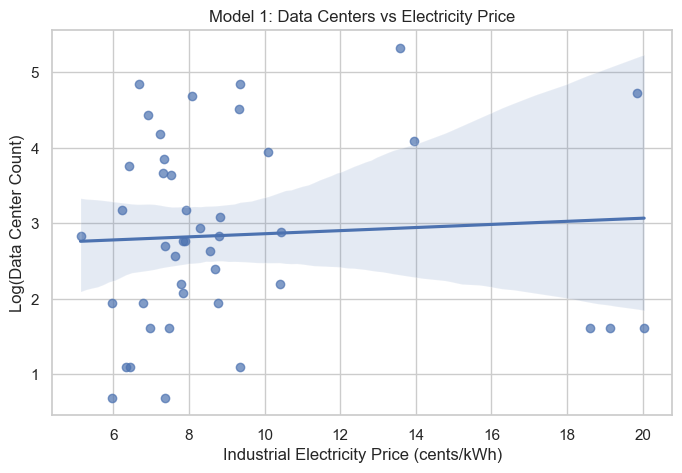

In [7]:
# Model 1: Data centers ~ Electricity Price

model1 = smf.ols(
    "log_data_center_count ~ electricity_price",
    data=reg_df
).fit()

print(model1.summary())


# Visualization
plt.figure(figsize=(8,5))
sns.regplot(
    data=reg_df,
    x="electricity_price",
    y="log_data_center_count",
    scatter_kws={"alpha":0.7}
)
plt.title("Model 1: Data Centers vs Electricity Price")
plt.xlabel("Industrial Electricity Price (cents/kWh)")
plt.ylabel("Log(Data Center Count)")
plt.show()

                              OLS Regression Results                             
Dep. Variable:     log_data_center_count   R-squared:                       0.165
Model:                               OLS   Adj. R-squared:                  0.145
Method:                    Least Squares   F-statistic:                     8.097
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):            0.00689
Time:                           01:22:25   Log-Likelihood:                -65.938
No. Observations:                     43   AIC:                             135.9
Df Residuals:                         41   BIC:                             139.4
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


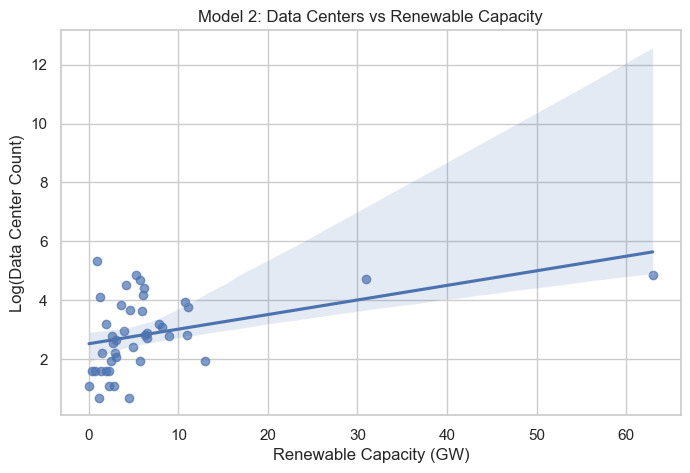

In [8]:
# Model 2: Data centers ~ Renewable Capacity


model2 = smf.ols(
    "log_data_center_count ~ renewable_capacity_gw",
    data=reg_df
).fit()

print(model2.summary())


# Visualization
plt.figure(figsize=(8,5))
sns.regplot(
    data=reg_df,
    x="renewable_capacity_gw",
    y="log_data_center_count",
    scatter_kws={"alpha":0.7}
)
plt.title("Model 2: Data Centers vs Renewable Capacity")
plt.xlabel("Renewable Capacity (GW)")
plt.ylabel("Log(Data Center Count)")
plt.show()

                              OLS Regression Results                             
Dep. Variable:     log_data_center_count   R-squared:                       0.011
Model:                               OLS   Adj. R-squared:                 -0.013
Method:                    Least Squares   F-statistic:                    0.4547
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):              0.504
Time:                           01:22:25   Log-Likelihood:                -69.576
No. Observations:                     43   AIC:                             143.2
Df Residuals:                         41   BIC:                             146.7
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


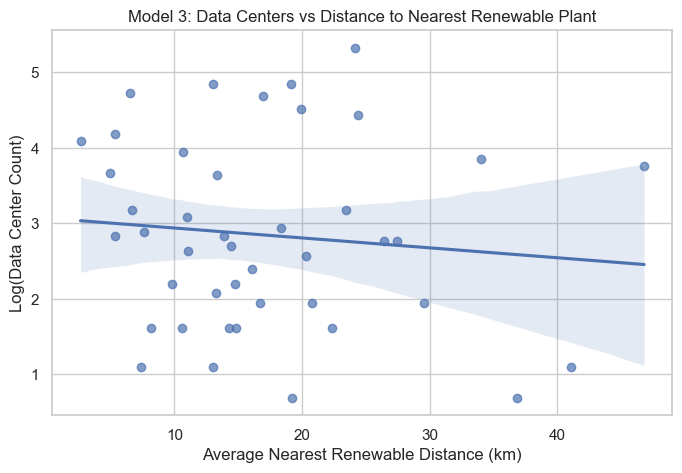

In [9]:
# Model 3: Data centers ~ Avg Distance to Renewable Plants


model3 = smf.ols(
    "log_data_center_count ~ avg_nearest_plants_km",
    data=reg_df
).fit()

print(model3.summary())


# Visualization
plt.figure(figsize=(8,5))
sns.regplot(
    data=reg_df,
    x="avg_nearest_plants_km",
    y="log_data_center_count",
    scatter_kws={"alpha":0.7}
)
plt.title("Model 3: Data Centers vs Distance to Nearest Renewable Plant")
plt.xlabel("Average Nearest Renewable Distance (km)")
plt.ylabel("Log(Data Center Count)")
plt.show()

                              OLS Regression Results                             
Dep. Variable:     log_data_center_count   R-squared:                       0.177
Model:                               OLS   Adj. R-squared:                  0.114
Method:                    Least Squares   F-statistic:                     2.799
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):             0.0526
Time:                           01:22:25   Log-Likelihood:                -65.621
No. Observations:                     43   AIC:                             139.2
Df Residuals:                         39   BIC:                             146.3
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


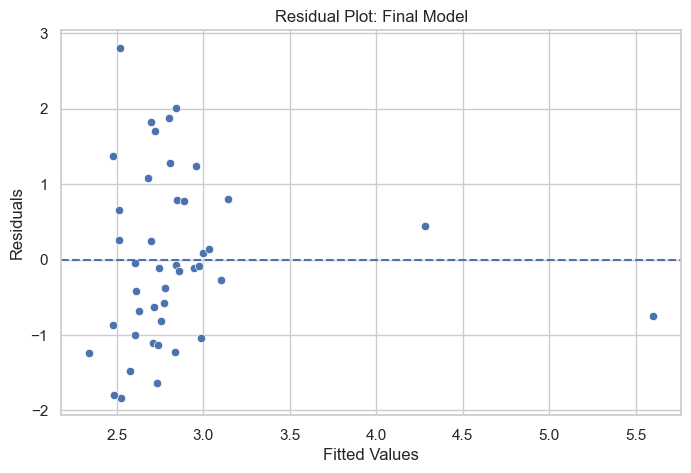

In [10]:
# Model 4: Combined Model


model4 = smf.ols(
    "log_data_center_count ~ electricity_price + renewable_capacity_gw + avg_nearest_plants_km",
    data=reg_df
).fit()

print(model4.summary())


# Residual plot for final model

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=model4.fittedvalues,
    y=model4.resid
)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot: Final Model")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [11]:
# Coefficient comparison table

results_table = pd.DataFrame({
    "Model 1": model1.params,
    "Model 2": model2.params,
    "Model 3": model3.params,
    "Model 4": model4.params
})

print(results_table)

                        Model 1   Model 2   Model 3   Model 4
Intercept              2.658675  2.524010  3.071148  2.658086
avg_nearest_plants_km       NaN       NaN -0.013133 -0.012397
electricity_price      0.020543       NaN       NaN  0.008516
renewable_capacity_gw       NaN  0.049528       NaN  0.049610


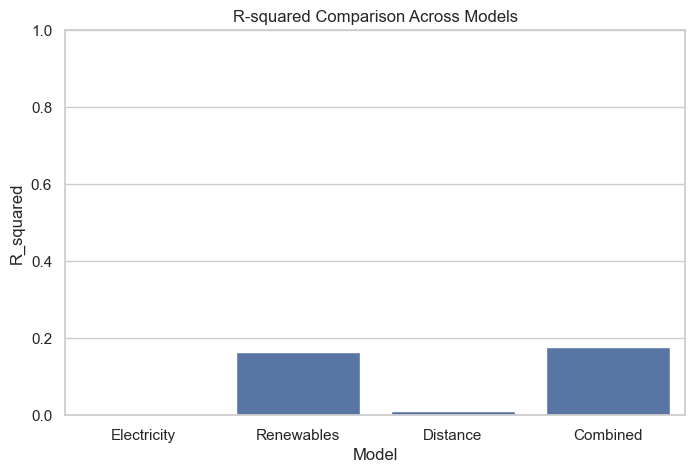

In [12]:
# R-squared comparison

r2_df = pd.DataFrame({
    "Model": ["Electricity", "Renewables", "Distance", "Combined"],
    "R_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(data=r2_df, x="Model", y="R_squared")
plt.title("R-squared Comparison Across Models")
plt.ylim(0,1)
plt.show()

## Logistic Regression Analysis

In [ ]:
real_df = gdf_data_centers[['state', 'lat', 'lon', 'geometry']].copy()
# Mark as positive case
real_df["is_datacenter"] = 1

# Create random comparison locations within bounding box of real data centers
minx, miny, maxx, maxy = gdf_data_centers.total_bounds
n_random = len(real_df)
random_points = []
while len(random_points) < n_random:
    rand_x = np.random.uniform(minx, maxx)
    rand_y = np.random.uniform(miny, maxy)
    random_points.append(Point(rand_x, rand_y))
random_gdf = gpd.GeoDataFrame(geometry=random_points, crs="EPSG:4326")

# Assign states to random points
try:
    os.environ["SHAPE_RESTORE_SHX"] = "YES"
    states_gdf = gpd.read_file("us_states_shapefile.shp").to_crs("EPSG:4326")

    random_gdf = gpd.sjoin(
        random_gdf,
        states_gdf[['NAME', 'geometry']],
        how='left',
        predicate='within'
    )

    random_gdf.rename(columns={"NAME": "state"}, inplace=True)
    random_gdf = random_gdf.dropna(subset=["state"]).copy()
except Exception as e:
    print(f"State polygon join unavailable: {e}")
    print("Falling back to state sampling from observed data center distribution.")
    state_probs = real_df["state"].value_counts(normalize=True)
    random_gdf["state"] = np.random.choice(
        state_probs.index,
        size=len(random_gdf),
        p=state_probs.values
    )

# Add lat/lon
random_gdf["lon"] = random_gdf.geometry.x
random_gdf["lat"] = random_gdf.geometry.y

# Mark as negative case
random_gdf["is_datacenter"] = 0
random_df = random_gdf[['state', 'lat', 'lon', 'geometry', 'is_datacenter']].copy()

# Combine real and random data
combined = pd.concat([real_df, random_df], ignore_index=True)
combined_gdf = gpd.GeoDataFrame(combined, geometry="geometry", crs="EPSG:4326")
# Add electricity prices
combined_gdf = combined_gdf.merge(
    electricity_price_df[['state', 'electricity_price']],
    on='state',
    how='left'
)

# Calculate nearest renewable plant distance
combined_proj = combined_gdf.to_crs(epsg=3857)
renew_proj = gdf_plants.to_crs(epsg=3857)
nearest = gpd.sjoin_nearest(
    combined_proj,
    renew_proj[['geometry']],
    how='left',
    distance_col='distance_m'
)
nearest["nearest_renew_km"] = nearest["distance_m"] / 1000


# Clean data
logit_df = nearest[
    ['is_datacenter', 'electricity_price', 'nearest_renew_km']
] .dropna().copy()

# Logistic Regression
model = smf.logit(
    "is_datacenter ~ electricity_price + nearest_renew_km",
    data=logit_df
).fit()
print(model.summary())


State polygon join unavailable: Cannot transform naive geometries.  Please set a crs on the object first.
Falling back to state sampling from observed data center distribution.
Optimization terminated successfully.
         Current function value: 0.438119
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          is_datacenter   No. Observations:                 2971
Model:                          Logit   Df Residuals:                     2968
Method:                           MLE   Df Model:                            2
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.3679
Time:                        01:57:27   Log-Likelihood:                -1301.7
converged:                       True   LL-Null:                       -2059.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
---

In [21]:
# Odds Ratios
odds_ratios = np.exp(model.params)
print("\nOdds Ratios:")
print(odds_ratios)

# Predicted probabilities
logit_df["pred_prob"] = model.predict(logit_df)

# Classification Metrics

logit_df["pred_class"] = (logit_df["pred_prob"] >= 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(logit_df["is_datacenter"], logit_df["pred_class"]))

print("\nClassification Report:")
print(classification_report(logit_df["is_datacenter"], logit_df["pred_class"]))

print("\nROC AUC Score:")
print(roc_auc_score(logit_df["is_datacenter"], logit_df["pred_prob"]))


Odds Ratios:
Intercept            11.396593
electricity_price     0.950804
nearest_renew_km      0.942852
dtype: float64

Confusion Matrix:
[[1051  447]
 [ 123 1350]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1498
           1       0.75      0.92      0.83      1473

    accuracy                           0.81      2971
   macro avg       0.82      0.81      0.81      2971
weighted avg       0.82      0.81      0.81      2971


ROC AUC Score:
0.8508198756975809


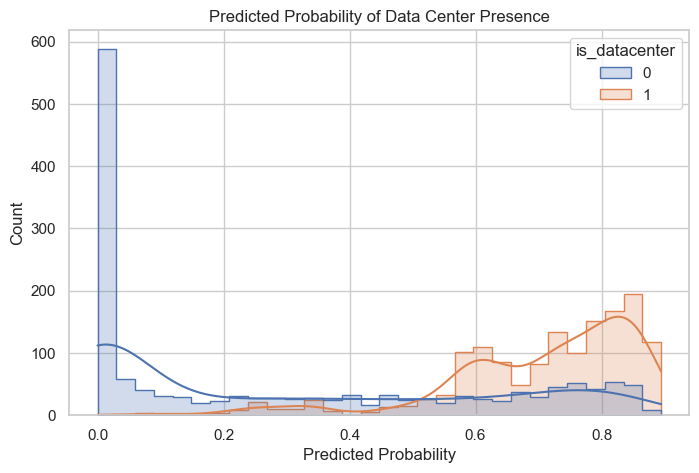

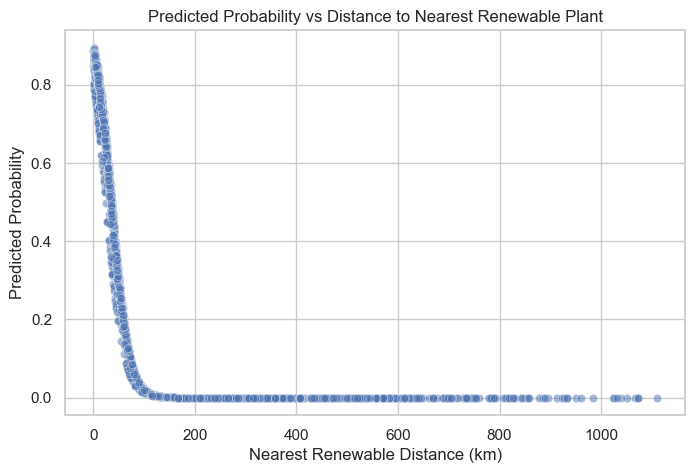

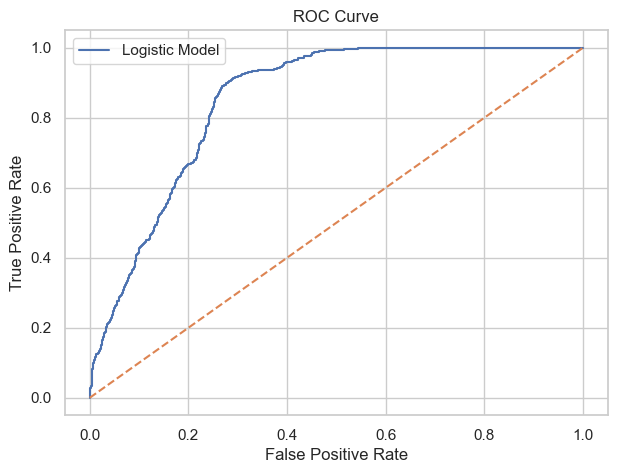

In [22]:
# Predicted probability distribution
plt.figure(figsize=(8,5))
sns.histplot(
    data=logit_df,
    x="pred_prob",
    hue="is_datacenter",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Predicted Probability of Data Center Presence")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()


# Probability vs Distance
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=logit_df,
    x="nearest_renew_km",
    y="pred_prob",
    alpha=0.5
)
plt.title("Predicted Probability vs Distance to Nearest Renewable Plant")
plt.xlabel("Nearest Renewable Distance (km)")
plt.ylabel("Predicted Probability")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(
    logit_df["is_datacenter"],
    logit_df["pred_prob"]
)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Logistic Model")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()